In [1]:
from blackjack import Game
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

In [2]:
Q = defaultdict(lambda: [0,0])
td_total = list()
epsilon_total = list()

In [3]:
def decideAction(state):
    outcomes = ["Off Policy", "On Policy"]
    probabilities = [epsilon, 1-epsilon] 

    # Sample two outcomes with replacement
    decision = random.choices(outcomes, weights=probabilities, k=1)[0]
    if decision == "Off Policy":
        return random.sample([0,1], 1)[0]
    elif decision == "On Policy":
        return np.argmax(Q[state])

In [4]:
epsilon = 1
epsilon_total.append(epsilon)
gamma = 0.9
alpha = 0.3
games = range(1,750001)

In [5]:
for i in games:
    if i%1000 == 0:
        epsilon -= 0.001333333333
        epsilon = max(epsilon, .15)
        epsilon_total.append(epsilon)
    if i%10000 == 0:
        print("Game ", i)
    game = Game()
    state, initial_reward = game.deal()
    didPlayerFinishTurn = False


    while game.is_game_over(didPlayerFinishTurn) is False:
        action = decideAction(state)
        if action == 0:
            didPlayerFinishTurn = True
        
        next_state, current_reward = game.make_action(action)

        if game.calc_value_of_hand(game.player_hand) > 21:
            didPlayerFinishTurn = True
        
        Q_old = Q[state][action]
        td = current_reward + gamma * max(Q[next_state]) - Q_old
        Q[state][action] = Q_old + alpha * td
        state = next_state
        td_total.append(td)

Game  10000
Game  20000
Game  30000
Game  40000
Game  50000
Game  60000
Game  70000
Game  80000
Game  90000
Game  100000
Game  110000
Game  120000
Game  130000
Game  140000
Game  150000
Game  160000
Game  170000
Game  180000
Game  190000
Game  200000
Game  210000
Game  220000
Game  230000
Game  240000
Game  250000


KeyboardInterrupt: 

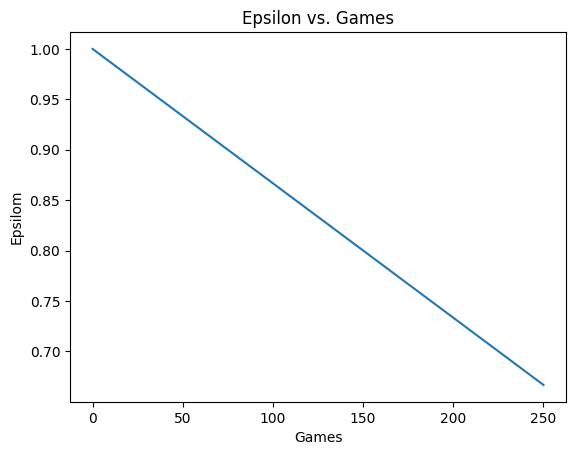

In [6]:
# Plot the data
plt.plot(range(len(epsilon_total)), epsilon_total)

# Add labels and title (optional)
plt.xlabel("Games")
plt.ylabel("Epsilom")
plt.title("Epsilon vs. Games")

# Show the plot
plt.show()

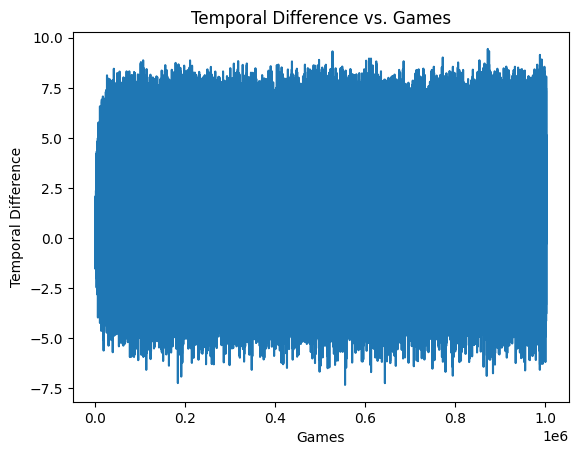

In [ ]:
# Plot the data
plt.plot(range(len(td_total)), td_total)

# Add labels and title (optional)
plt.xlabel("Games")
plt.ylabel("Temporal Difference")
plt.title("Temporal Difference vs. Games")

# Show the plot
plt.show()